In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
quize1 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/dataset/marks/quiz1/quiz1_marks.csv')
quize2 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/dataset/marks/quiz2/quiz2_marks.csv')
quize3 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/dataset/marks/quiz3/quiz3_marks.csv')


In [24]:

quize1.head()

,Student Code,State,Started on,Completed,Time taken,Grade/10.00,Q. 1 /2.00,Q. 2 /2.00,Q. 3 /2.00,Q. 4 /2.00,Q. 5 /2.00,Time taken (seconds)
0,1,Finished,14 March 2022 6:55 AM,14 March 2022 7:03 AM,7 mins 25 secs,6.00,0.00,2.00,2.00,2.00,0.00,445.0
1,1,Finished,14 March 2022 7:11 AM,14 March 2022 7:12 AM,1 min 4 secs,10.00,2.00,2.00,2.00,2.00,2.00,64.0
3,5,Finished,14 March 2022 12:00 PM,14 March 2022 12:18 PM,17 mins 53 secs,6.00,2.00,2.00,2.00,0.00,0.00,1073.0
4,5,Finished,14 March 2022 12:19 PM,14 March 2022 12:20 PM,56 secs,10.00,2.00,2.00,2.00,2.00,2.00,56.0
5,3,Finished,14 March 2022 3:14 PM,14 March 2022 3:18 PM,4 mins 26 secs,4.00,0.00,2.00,0.00,2.00,0.00,266.0


In [22]:
import re
import numpy as np

def convert_time_to_seconds(time_str):
    if not isinstance(time_str, str) or time_str.strip() == '-' or time_str.strip() == '':
        return np.nan

    minutes = 0
    seconds = 0

    min_match = re.search(r'(\d+)\s*min(?:s)?', time_str)
    if min_match:
        minutes = int(min_match.group(1))

    sec_match = re.search(r'(\d+)\s*sec(?:s)?', time_str)
    if sec_match:
        seconds = int(sec_match.group(1))

    return minutes * 60 + seconds

quize1['Time taken (seconds)'] = quize1['Time taken'].apply(convert_time_to_seconds)
quize2['Time taken (seconds)'] = quize2['Time taken'].apply(convert_time_to_seconds)
quize3['Time taken (seconds)'] = quize3['Time taken'].apply(convert_time_to_seconds)

print("Updated quize1 dataframe head with new 'Time taken (seconds)' column:")
print(quize1[['Time taken', 'Time taken (seconds)']].head())

Updated quize1 dataframe head with new 'Time taken (seconds)' column:
        Time taken  Time taken (seconds)
0   7 mins 25 secs                 445.0
1     1 min 4 secs                  64.0
2                -                   NaN
3  17 mins 53 secs                1073.0
4          56 secs                  56.0


In [23]:
# Re-apply the conversion to get original NaNs in 'Time taken (seconds)'
# This is necessary as the previous 'fillna' operation would have modified the column.
quize1['Time taken (seconds)'] = quize1['Time taken'].apply(convert_time_to_seconds)
quize2['Time taken (seconds)'] = quize2['Time taken'].apply(convert_time_to_seconds)
quize3['Time taken (seconds)'] = quize3['Time taken'].apply(convert_time_to_seconds)

# Process quize1
initial_rows_quize1 = len(quize1)
quize1.dropna(subset=['Time taken (seconds)'], inplace=True)
dropped_rows_quize1 = initial_rows_quize1 - len(quize1)
percentage_dropped_quize1 = (dropped_rows_quize1 / initial_rows_quize1) * 100 if initial_rows_quize1 > 0 else 0

# Process quize2
initial_rows_quize2 = len(quize2)
quize2.dropna(subset=['Time taken (seconds)'], inplace=True)
dropped_rows_quize2 = initial_rows_quize2 - len(quize2)
percentage_dropped_quize2 = (dropped_rows_quize2 / initial_rows_quize2) * 100 if initial_rows_quize2 > 0 else 0

# Process quize3
initial_rows_quize3 = len(quize3)
quize3.dropna(subset=['Time taken (seconds)'], inplace=True)
dropped_rows_quize3 = initial_rows_quize3 - len(quize3)
percentage_dropped_quize3 = (dropped_rows_quize3 / initial_rows_quize3) * 100 if initial_rows_quize3 > 0 else 0

print(f"Percentage of rows dropped in quize1: {percentage_dropped_quize1:.2f}%")
print(f"Percentage of rows dropped in quize2: {percentage_dropped_quize2:.2f}%")
print(f"Percentage of rows dropped in quize3: {percentage_dropped_quize3:.2f}%")

Percentage of rows dropped in quize1: 0.56%
Percentage of rows dropped in quize2: 0.42%
Percentage of rows dropped in quize3: 0.82%


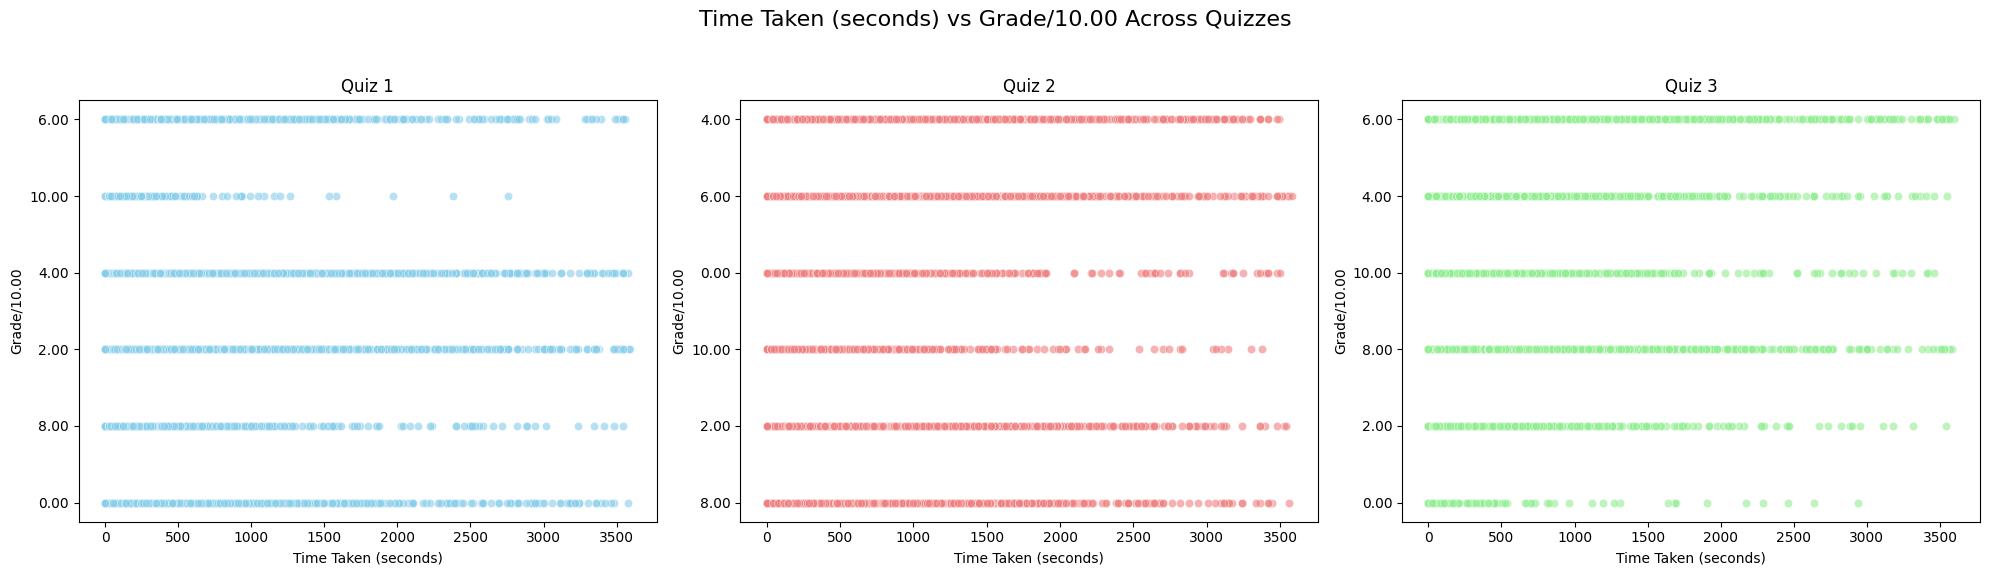

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Time Taken (seconds) vs Grade/10.00 Across Quizzes', fontsize=16)

# Scatter plot for Quiz 1
sns.scatterplot(x='Time taken (seconds)', y='Grade/10.00', data=quize1, ax=axes[0], alpha=0.6, color='skyblue')
axes[0].set_title('Quiz 1')
axes[0].set_xlabel('Time Taken (seconds)')
axes[0].set_ylabel('Grade/10.00')

# Scatter plot for Quiz 2
sns.scatterplot(x='Time taken (seconds)', y='Grade/10.00', data=quize2, ax=axes[1], alpha=0.6, color='lightcoral')
axes[1].set_title('Quiz 2')
axes[1].set_xlabel('Time Taken (seconds)')
axes[1].set_ylabel('Grade/10.00')

# Scatter plot for Quiz 3
sns.scatterplot(x='Time taken (seconds)', y='Grade/10.00', data=quize3, ax=axes[2], alpha=0.6, color='lightgreen')
axes[2].set_title('Quiz 3')
axes[2].set_xlabel('Time Taken (seconds)')
axes[2].set_ylabel('Grade/10.00')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()